<a href="https://colab.research.google.com/github/SAINIDHI2005/IDS_GNN_Repo/blob/main/graphSAGE/KNN_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.8 MB/s eta 0:00:00


In [3]:
import os

import pandas as pd
import numpy as np

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data

In [4]:
import os
import pandas as pd
DATASET_DIR = "/content/drive/MyDrive/CIC_IoT_2023/New_Disjoint_200K"


dfs = []

# -------------------------
# BENIGN
# -------------------------

benign = pd.read_csv(
    os.path.join(DATASET_DIR, "Benign_100K.csv")
)

benign = benign.iloc[:90000].copy()

benign["attack_type"] = "BENIGN"
benign["label"] = 0

dfs.append(benign)

# -------------------------
# DDOS
# -------------------------

ddos = pd.read_csv(
    os.path.join(DATASET_DIR, "DDoS_20K.csv")
)

ddos = ddos.iloc[:2000].copy()

ddos["attack_type"] = "DDoS_20K"
ddos["label"] = 1

dfs.append(ddos)

# -------------------------
# DOS
# -------------------------

dos = pd.read_csv(
    os.path.join(DATASET_DIR, "DoS_20K.csv")
)

dos = dos.iloc[:2000].copy()

dos["attack_type"] = "DoS_20K"
dos["label"] = 1

dfs.append(dos)

# -------------------------
# MIRAI
# -------------------------

mirai = pd.read_csv(
    os.path.join(DATASET_DIR, "Mirai_20K.csv")
)

mirai = mirai.iloc[:2000].copy()

mirai["attack_type"] = "Mirai_20K"
mirai["label"] = 1

dfs.append(mirai)

# -------------------------
# RECON
# -------------------------

recon = pd.read_csv(
    os.path.join(DATASET_DIR, "Recon_20K.csv")
)

recon = recon.iloc[:2000].copy()

recon["attack_type"] = "Recon_20K"
recon["label"] = 1

dfs.append(recon)

# -------------------------
# SPOOFING
# -------------------------

spoof = pd.read_csv(
    os.path.join(DATASET_DIR, "Spoofing_20K.csv")
)

spoof = spoof.iloc[:2000].copy()

spoof["attack_type"] = "Spoofing_20K"
spoof["label"] = 1

dfs.append(spoof)

# -------------------------
# COMBINE
# -------------------------

data = pd.concat(
    dfs,
    ignore_index=True
)

print(data.shape)

print("\nAttack Distribution:\n")
print(data["attack_type"].value_counts())

(100000, 88)

Attack Distribution:

attack_type
BENIGN          90000
DDoS_20K         2000
DoS_20K          2000
Mirai_20K        2000
Recon_20K        2000
Spoofing_20K     2000
Name: count, dtype: int64


In [5]:
data = data.sort_values(
    "bidirectional_first_seen_ms"
).reset_index(drop=True)

data["flow_id"] = np.arange(len(data))

print(data.shape)

(100000, 89)


In [6]:
attack_type_backup = data["attack_type"].copy()

In [7]:
DROP_COLS = [

    "id",
    "expiration_id",

    "src_ip",
    "dst_ip",


   # "dst_port",
    #"src_port",
    #"protocol",
   # "ip_version"

    "src_mac",
    "dst_mac",

    "src_oui",
    "dst_oui",

    "requested_server_name",

    "client_fingerprint",
    "server_fingerprint",

    "user_agent",
    "content_type",

    "application_name",
    "application_category_name",

    "flow_id",
    "label",
    "attack_type",

    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",

    "src2dst_first_seen_ms",
    "src2dst_last_seen_ms",

    "dst2src_first_seen_ms",
    "dst2src_last_seen_ms",

    "application_confidence",
    "application_is_guessed",

    "vlan_id",
    "tunnel_id",

    "bidirectional_urg_packets",
    "src2dst_urg_packets",
    "dst2src_urg_packets",

    "dst2src_cwr_packets",
    "dst2src_ece_packets",

    "src_port",

    "bidirectional_duration_ms",
    "bidirectional_packets",

    "src2dst_packets",
    "dst2src_packets",

    "dst2src_min_ps",
    "dst2src_mean_ps",

    "bidirectional_min_piat_ms",
    "bidirectional_stddev_piat_ms",

    "dst2src_min_piat_ms",
    "dst2src_mean_piat_ms",
    "dst2src_max_piat_ms",

    "bidirectional_ece_packets",
    "bidirectional_psh_packets",
    "bidirectional_fin_packets",

    "src2dst_syn_packets",
    "src2dst_cwr_packets",
    "src2dst_ack_packets",
    "src2dst_rst_packets",
    "src2dst_fin_packets",

    "src2dst_mean_piat_ms",
    "src2dst_stddev_ps",

    "dst2src_ack_packets",
    "dst2src_psh_packets",
    "dst2src_rst_packets",
    "dst2src_fin_packets",

]

feature_cols = [

    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:",len(feature_cols))

Features: 30


In [8]:
feature_cols = [
    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:", len(feature_cols))

print("\nRetained Features:\n")
for i, f in enumerate(feature_cols, start=1):
    print(f"{i:2d}. {f}")

Features: 30

Retained Features:

 1. dst_port
 2. protocol
 3. ip_version
 4. bidirectional_bytes
 5. src2dst_duration_ms
 6. src2dst_bytes
 7. dst2src_duration_ms
 8. dst2src_bytes
 9. bidirectional_min_ps
10. bidirectional_mean_ps
11. bidirectional_stddev_ps
12. bidirectional_max_ps
13. src2dst_min_ps
14. src2dst_mean_ps
15. src2dst_max_ps
16. dst2src_stddev_ps
17. dst2src_max_ps
18. bidirectional_mean_piat_ms
19. bidirectional_max_piat_ms
20. src2dst_min_piat_ms
21. src2dst_stddev_piat_ms
22. src2dst_max_piat_ms
23. dst2src_stddev_piat_ms
24. bidirectional_syn_packets
25. bidirectional_cwr_packets
26. bidirectional_ack_packets
27. bidirectional_rst_packets
28. src2dst_ece_packets
29. src2dst_psh_packets
30. dst2src_syn_packets


In [9]:
top30 = {
    "bidirectional_mean_ps",
    "dst2src_syn_packets",
    "src2dst_min_ps",
    "ip_version",
    "src2dst_max_piat_ms",
    "dst2src_stddev_piat_ms",
    "bidirectional_max_piat_ms",
    "bidirectional_rst_packets",
    "src2dst_max_ps",
    "src2dst_duration_ms",
    "src2dst_bytes",
    "src2dst_ece_packets",
    "bidirectional_max_ps",
    "dst2src_bytes",
    "bidirectional_bytes",
    "dst2src_max_ps",
    "bidirectional_min_ps",
    "bidirectional_syn_packets",
    "dst2src_stddev_ps",
    "bidirectional_ack_packets",
    "protocol",
    "dst_port",
    "bidirectional_mean_piat_ms",
    "dst2src_duration_ms",
    "src2dst_mean_ps",
    "src2dst_min_piat_ms",
    "bidirectional_stddev_ps",
    "src2dst_stddev_piat_ms",
    "bidirectional_cwr_packets",
    "src2dst_psh_packets"
}

retained = set(feature_cols)

print("Missing from retained:")
print(sorted(top30 - retained))

print("\nExtra retained features:")
print(sorted(retained - top30))

Missing from retained:
[]

Extra retained features:
[]


In [10]:
for col in feature_cols:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data[feature_cols] = (
    data[feature_cols]
    .fillna(0)
)

In [11]:
import joblib

scaler = joblib.load(
    r"/content/drive/MyDrive/CIC_IoT_2023/Saved_Model/KNN_scaler.pkl"
)

feature_cols = list(scaler.feature_names_in_)

X_scaled = scaler.transform(
    data[feature_cols]
)

print(X_scaled.shape)

(100000, 30)


In [12]:
from sklearn.neighbors import kneighbors_graph
from torch_geometric.utils import from_scipy_sparse_matrix

K = 15

A = kneighbors_graph(
    X_scaled,
    n_neighbors=K,
    mode='connectivity',
    include_self=False
)

edge_index, _ = from_scipy_sparse_matrix(A)

print(edge_index.shape)

torch.Size([2, 1500000])


In [13]:
from torch_geometric.data import Data

graph = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(
        data["label"].values,
        dtype=torch.long
    )
)

print(graph)
print("Nodes:", graph.num_nodes)
print("Edges:", graph.num_edges)

Data(x=[100000, 30], edge_index=[2, 1500000], y=[100000])
Nodes: 100000
Edges: 1500000


In [14]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv


class GraphSAGE(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        num_classes
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = SAGEConv(
            hidden_channels,
            hidden_channels
        )

        self.linear = torch.nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(
        self,
        x,
        edge_index
    ):

        # GraphSAGE Layer 1
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        # GraphSAGE Layer 2
        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        # Classification Layer
        x = self.linear(x)

        return x

In [15]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [16]:
checkpoint = torch.load(
    "/content/drive/MyDrive/CIC_IoT_2023/Saved_Model/KNN_graphSAGE.pth",
    map_location="cpu"
)

for k in checkpoint.keys():
    print(k)

conv1.lin_l.weight
conv1.lin_l.bias
conv1.lin_r.weight
conv2.lin_l.weight
conv2.lin_l.bias
conv2.lin_r.weight
linear.weight
linear.bias


In [17]:
print(graph.num_node_features)

30


In [18]:
import torch

model = GraphSAGE(
    in_channels=graph.num_node_features,
    hidden_channels=256,
    num_classes=2
)

model.load_state_dict(
    torch.load(
        r"/content/drive/MyDrive/CIC_IoT_2023/Saved_Model/KNN_graphSAGE.pth",
        map_location=device
    )
)

model = model.to(device)
graph = graph.to(device)

model.eval()

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [19]:
with torch.no_grad():

    logits = model(
        graph.x,
        graph.edge_index
    )

print(logits.shape)

torch.Size([100000, 2])


In [20]:
print("Logits Shape:", logits.shape)
print("Graph Nodes :", graph.num_nodes)

Logits Shape: torch.Size([100000, 2])
Graph Nodes : 100000


In [21]:
probs = torch.softmax(
    logits,
    dim=1
)

attack_prob = probs[:,1]

import time

start = time.time()

pred = (
    attack_prob > 0.66
).long().cpu().numpy()

print(pred.shape)

(100000,)


In [22]:
end = time.time()

print(
    f"Inference Time: "
    f"{end-start:.4f} seconds"
)

Inference Time: 0.0576 seconds


In [23]:
y_true = (
    graph.y
    .cpu()
    .numpy()
)

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(y_true,pred)
)

print(
    "Precision:",
    precision_score(y_true,pred)
)

print(
    "Recall:",
    recall_score(y_true,pred)
)

print(
    "F1:",
    f1_score(y_true,pred)
)

print(
    classification_report(
        y_true,
        pred
    )
)

Accuracy: 0.85963
Precision: 0.4019336345527863
Recall: 0.8273
F1: 0.5410195206487264
              precision    recall  f1-score   support

           0       0.98      0.86      0.92     90000
           1       0.40      0.83      0.54     10000

    accuracy                           0.86    100000
   macro avg       0.69      0.85      0.73    100000
weighted avg       0.92      0.86      0.88    100000



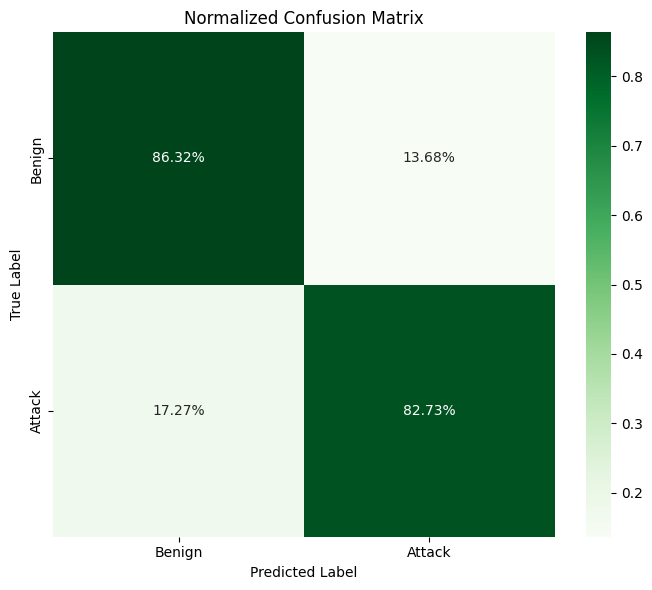

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# True labels
#y_true = graph.y[graph.test_mask].cpu().numpy()

# Predicted labels
#y_pred = pred[graph.test_mask].cpu().numpy()

# Confusion matrix
cm = confusion_matrix(y_true, pred)

# Normalize row-wise
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=["Benign", "Attack"],
    yticklabels=["Benign", "Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

In [26]:
attack_types = data["attack_type"].values

results = []

for attack in ["DDoS_20K", "DoS_20K", "Mirai_20K", "Recon_20K", "Spoofing_20K"]:

    idx = (attack_types == attack)

    total = idx.sum()

    detected = ((pred == 1) & idx).sum()

    missed = ((pred == 0) & idx).sum()

    recall = detected / total

    results.append([
        attack,
        total,
        detected,
        missed,
        recall * 100
    ])

import pandas as pd

attack_results = pd.DataFrame(
    results,
    columns=[
        "Attack",
        "Total",
        "Detected",
        "Missed",
        "Recall_%"
    ]
)

print("\n===== ATTACK DETECTION BREAKDOWN =====\n")
print(attack_results)


===== ATTACK DETECTION BREAKDOWN =====

         Attack  Total  Detected  Missed  Recall_%
0      DDoS_20K   2000      1985      15     99.25
1       DoS_20K   2000      1912      88     95.60
2     Mirai_20K   2000      1416     584     70.80
3     Recon_20K   2000      1677     323     83.85
4  Spoofing_20K   2000      1283     717     64.15


In [27]:
attack_results["Recall_%"] = attack_results["Recall_%"].round(3)

print(
    attack_results.sort_values(
        "Recall_%",
        ascending=False
    )
)

         Attack  Total  Detected  Missed  Recall_%
0      DDoS_20K   2000      1985      15     99.25
1       DoS_20K   2000      1912      88     95.60
3     Recon_20K   2000      1677     323     83.85
2     Mirai_20K   2000      1416     584     70.80
4  Spoofing_20K   2000      1283     717     64.15


In [28]:
import torch

print(
    f"Allocated GPU Memory: "
    f"{torch.cuda.memory_allocated()/1024**2:.2f} MB"
)

print(
    f"Reserved GPU Memory: "
    f"{torch.cuda.memory_reserved()/1024**2:.2f} MB"
)

print(
    f"Max GPU Memory: "
    f"{torch.cuda.max_memory_allocated()/1024**2:.2f} MB"
)

Allocated GPU Memory: 46.87 MB
Reserved GPU Memory: 1908.00 MB
Max GPU Memory: 1804.22 MB


In [29]:
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters:", total_params)
print("Trainable Parameters:", trainable_params)

Total Parameters: 147458
Trainable Parameters: 147458


In [30]:
num_nodes = graph.num_nodes
num_edges = graph.num_edges

node_memory = (
    graph.x.element_size()
    * graph.x.nelement()
)

edge_memory = (
    graph.edge_index.element_size()
    * graph.edge_index.nelement()
)

print(
    f"Node Feature Memory: "
    f"{node_memory/1024**2:.2f} MB"
)

print(
    f"Edge Memory: "
    f"{edge_memory/1024**2:.2f} MB"
)

print(
    f"Total Graph Memory: "
    f"{(node_memory+edge_memory)/1024**2:.2f} MB"
)

Node Feature Memory: 11.44 MB
Edge Memory: 22.89 MB
Total Graph Memory: 34.33 MB


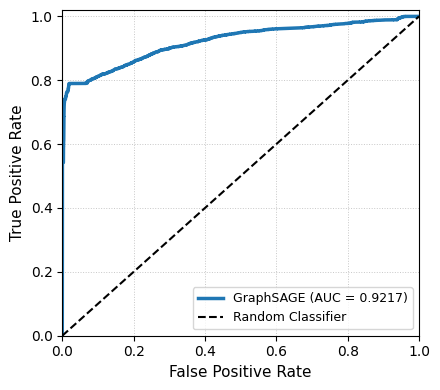

AUC Score : 0.9217


In [32]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

# ----------------------------
# Model Inference
# ----------------------------
model.eval()

with torch.no_grad():

    logits = model(
        graph.x.to(device),
        graph.edge_index.to(device)
    )

# Flow node predictions only
flow_logits = logits[:num_nodes]

# Probability of Attack class
attack_prob = torch.softmax(
    flow_logits,
    dim=1
)[:, 1].cpu().numpy()

# Ground truth labels
labels = graph.y[:num_nodes].cpu().numpy()

# ----------------------------
# ROC & AUC
# ----------------------------
fpr, tpr, _ = roc_curve(
    labels,
    attack_prob
)

roc_auc = auc(
    fpr,
    tpr
)

# ----------------------------
# IEEE Style Plot
# ----------------------------
plt.figure(figsize=(4.5, 4.0))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"GraphSAGE (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Random Classifier"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.xlabel(
    "False Positive Rate",
    fontsize=11
)

plt.ylabel(
    "True Positive Rate",
    fontsize=11
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(
    linestyle=":",
    linewidth=0.7,
    alpha=0.7
)

plt.legend(
    loc="lower right",
    fontsize=9,
    frameon=True
)

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "ROC_GraphSAGE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"AUC Score : {roc_auc:.4f}")